In [70]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt  
from litellm import completion
from dotenv import load_dotenv
import os

import warnings

from IPython.display import Markdown, display

# Hide warnings
warnings.filterwarnings("ignore")

# Load .env variables
load_dotenv()

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [71]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [82]:
COUNTRY = 'United Kingdom'
JOB_TITLE = 'Data Analyst'
df_country_raw = df[(df['job_country']== COUNTRY)&(df['job_title_short'] == JOB_TITLE)].copy()
df_country_raw['job_posted_month_no'] = df_country_raw['job_posted_date'].dt.month

df_country_raw
df_country = df_country_raw.explode('job_skills')
df_country




,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,sql,"{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,r,"{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,python,"{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,tableau,"{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,power bi,"{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785061,Data Analyst,Data Analyst,"Manchester, UK",via LinkedIn,Contractor,False,United Kingdom,2023-11-23 06:17:48,True,False,United Kingdom,NaN,NaN,NaN,Quooker UK,NaN,NaN,11
785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,sql,"{'analyst_tools': ['excel', 'powerpoint'], 'da...",10
785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,sql server,"{'analyst_tools': ['excel', 'powerpoint'], 'da...",10
785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,excel,"{'analyst_tools': ['excel', 'powerpoint'], 'da...",10


In [83]:
print(COUNTRY)

def answer(dataframe):
    system_prompt = f"""
You are an expert data analyst and career insights assistant for {COUNTRY} and {JOB_TITLE}.

You will be given a pandas DataFrame containing job market analysis data. Your task is to analyze the data carefully and generate exactly 3 concise, high-value bullet point insights that would genuinely help someone searching for a job.

Focus on insights such as:
- Most in-demand skills
- Highest-paying skills or roles
- Hiring trends
- Locations with strong opportunities
- Remote work trends
- Experience-level demand
- Industry demand patterns

Requirements:
- Keep each insight practical and actionable.
- Use clear and simple language.
- Include numbers, percentages, or comparisons whenever possible.
- Avoid generic observations.
- Prioritize insights that can help a job seeker make better career decisions.
- Keep each bullet point under 35 words.
- Output only the 3 bullet points and nothing else.

DataFrame:
{dataframe.head(20).to_string()}
"""

    response = completion(
        #openrouter/inclusionai/ring-2.6-1t:free
        #openrouter/openai/gpt-oss-120b:free
        
    model="openrouter/openai/gpt-oss-20b:free",
    messages=[
        {"role": "system", "content": system_prompt },
        {"role": "user", "content": "Give me key insights for job seekers" }
    ],
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
    )
    return response.choices[0].message.content







United Kingdom


In [84]:
df_da_piviot = df_country.pivot_table( index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_da_piviot

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asana,asp.net,assembly,atlassian,...,vmware,vue,vue.js,watson,windows,wire,word,workfront,wsl,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,4,2,31,0,0,0,1,0,0,1,...,1,1,0,0,14,0,68,0,1,2
2,0,0,13,0,0,0,0,0,3,0,...,7,0,0,0,10,0,55,1,0,1
3,2,0,12,0,0,0,0,0,0,0,...,1,0,0,0,4,0,41,0,0,1
4,1,0,13,0,0,0,0,0,1,1,...,2,0,1,0,8,0,27,0,0,0
5,3,4,13,0,0,0,0,0,1,1,...,0,0,0,0,0,0,28,0,0,1
6,3,0,3,0,0,0,0,0,1,1,...,0,1,2,0,1,0,38,0,0,0
7,8,0,9,0,1,0,0,0,1,0,...,3,0,2,0,4,0,49,0,0,0
8,4,0,1,0,0,0,1,0,0,0,...,3,0,0,0,6,3,28,0,0,2
9,3,0,19,0,2,2,6,0,0,0,...,4,0,0,1,8,0,53,0,0,2


In [85]:
df_da_piviot.loc['Total'] = df_da_piviot.sum()

df_da_piviot

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asana,asp.net,assembly,atlassian,...,vmware,vue,vue.js,watson,windows,wire,word,workfront,wsl,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,4,2,31,0,0,0,1,0,0,1,...,1,1,0,0,14,0,68,0,1,2
2,0,0,13,0,0,0,0,0,3,0,...,7,0,0,0,10,0,55,1,0,1
3,2,0,12,0,0,0,0,0,0,0,...,1,0,0,0,4,0,41,0,0,1
4,1,0,13,0,0,0,0,0,1,1,...,2,0,1,0,8,0,27,0,0,0
5,3,4,13,0,0,0,0,0,1,1,...,0,0,0,0,0,0,28,0,0,1
6,3,0,3,0,0,0,0,0,1,1,...,0,1,2,0,1,0,38,0,0,0
7,8,0,9,0,1,0,0,0,1,0,...,3,0,2,0,4,0,49,0,0,0
8,4,0,1,0,0,0,1,0,0,0,...,3,0,0,0,6,3,28,0,0,2
9,3,0,19,0,2,2,6,0,0,0,...,4,0,0,1,8,0,53,0,0,2


In [86]:
df_da_sorted = df_da_piviot[df_da_piviot.loc['Total'].sort_values(ascending=False).index]

df_da_sorted = df_da_sorted.drop('Total')
df_da_sorted

job_skills,sql,excel,power bi,python,tableau,r,sas,azure,go,powerpoint,...,selenium,flutter,fortran,redis,golang,ionic,kotlin,laravel,node,next.js
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,607,581,371,266,204,141,126,73,54,78,...,0,1,0,0,0,0,0,0,1,0
2,450,479,287,179,171,91,92,65,46,45,...,0,0,0,0,0,0,0,0,0,0
3,301,299,174,120,117,67,52,38,42,43,...,0,0,0,0,0,0,0,0,0,0
4,230,227,160,90,75,47,38,32,27,39,...,0,0,0,1,0,1,0,0,0,0
5,258,249,161,96,76,53,40,36,29,27,...,0,0,0,0,0,0,0,0,0,0
6,282,297,181,118,95,52,36,36,37,34,...,0,0,0,0,0,0,0,0,0,0
7,398,394,297,202,106,97,78,111,45,84,...,0,0,0,0,0,0,0,0,0,0
8,260,262,171,109,84,51,36,42,39,28,...,0,0,1,0,0,0,0,0,0,0
9,498,451,318,255,206,144,82,70,61,48,...,0,0,0,0,0,0,1,1,0,0


In [87]:
total_job = df_country_raw['job_posted_month_no'].value_counts()
total_jobs = total_job.reset_index(name='count')
total_jobs.sort_values(by='job_posted_month_no', ascending=True, inplace=True)
total_jobs

,job_posted_month_no,count
0,1,1467
3,2,1051
8,3,712
11,4,561
9,5,614
6,6,736
4,7,892
10,8,610
2,9,1112
1,10,1175


In [88]:
totals = df_country_raw.groupby('job_posted_month_no').size()

In [89]:
df_da_perc = df_da_sorted.div(totals/100, axis=0)
df_da_perc

job_skills,sql,excel,power bi,python,tableau,r,sas,azure,go,powerpoint,...,selenium,flutter,fortran,redis,golang,ionic,kotlin,laravel,node,next.js
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,41.376960,39.604635,25.289707,18.132243,13.905930,9.611452,8.588957,4.976142,3.680982,5.316973,...,0.000000,0.068166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.068166,0.000000
2,42.816365,45.575642,27.307326,17.031399,16.270219,8.658421,8.753568,6.184586,4.376784,4.281637,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,42.275281,41.994382,24.438202,16.853933,16.432584,9.410112,7.303371,5.337079,5.898876,6.039326,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,40.998217,40.463458,28.520499,16.042781,13.368984,8.377897,6.773619,5.704100,4.812834,6.951872,...,0.000000,0.000000,0.000000,0.178253,0.000000,0.178253,0.000000,0.000000,0.000000,0.000000
5,42.019544,40.553746,26.221498,15.635179,12.377850,8.631922,6.514658,5.863192,4.723127,4.397394,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,38.315217,40.353261,24.592391,16.032609,12.907609,7.065217,4.891304,4.891304,5.027174,4.619565,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,44.618834,44.170404,33.295964,22.645740,11.883408,10.874439,8.744395,12.443946,5.044843,9.417040,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,42.622951,42.950820,28.032787,17.868852,13.770492,8.360656,5.901639,6.885246,6.393443,4.590164,...,0.000000,0.000000,0.163934,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,44.784173,40.557554,28.597122,22.931655,18.525180,12.949640,7.374101,6.294964,5.485612,4.316547,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089928,0.089928,0.000000,0.000000


In [90]:
df_da_perc = df_da_perc.reset_index()
df_da_perc['job_posted_month'] = df_da_perc['job_posted_month_no'].apply(lambda x:pd.to_datetime(x, format='%m').strftime('%b'))
df_da_perc = df_da_perc.set_index('job_posted_month')
df_da_perc = df_da_perc.drop(columns='job_posted_month_no')
df_da_perc

job_skills,sql,excel,power bi,python,tableau,r,sas,azure,go,powerpoint,...,selenium,flutter,fortran,redis,golang,ionic,kotlin,laravel,node,next.js
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,41.376960,39.604635,25.289707,18.132243,13.905930,9.611452,8.588957,4.976142,3.680982,5.316973,...,0.000000,0.068166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.068166,0.000000
Feb,42.816365,45.575642,27.307326,17.031399,16.270219,8.658421,8.753568,6.184586,4.376784,4.281637,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,42.275281,41.994382,24.438202,16.853933,16.432584,9.410112,7.303371,5.337079,5.898876,6.039326,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,40.998217,40.463458,28.520499,16.042781,13.368984,8.377897,6.773619,5.704100,4.812834,6.951872,...,0.000000,0.000000,0.000000,0.178253,0.000000,0.178253,0.000000,0.000000,0.000000,0.000000
May,42.019544,40.553746,26.221498,15.635179,12.377850,8.631922,6.514658,5.863192,4.723127,4.397394,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,38.315217,40.353261,24.592391,16.032609,12.907609,7.065217,4.891304,4.891304,5.027174,4.619565,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,44.618834,44.170404,33.295964,22.645740,11.883408,10.874439,8.744395,12.443946,5.044843,9.417040,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,42.622951,42.950820,28.032787,17.868852,13.770492,8.360656,5.901639,6.885246,6.393443,4.590164,...,0.000000,0.000000,0.163934,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,44.784173,40.557554,28.597122,22.931655,18.525180,12.949640,7.374101,6.294964,5.485612,4.316547,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089928,0.089928,0.000000,0.000000


In [91]:
df_plot = df_da_perc.iloc[:,:5]
df_plot

job_skills,sql,excel,power bi,python,tableau
job_posted_month,,,,,
Jan,41.376960,39.604635,25.289707,18.132243,13.905930
Feb,42.816365,45.575642,27.307326,17.031399,16.270219
Mar,42.275281,41.994382,24.438202,16.853933,16.432584
Apr,40.998217,40.463458,28.520499,16.042781,13.368984
May,42.019544,40.553746,26.221498,15.635179,12.377850
Jun,38.315217,40.353261,24.592391,16.032609,12.907609
Jul,44.618834,44.170404,33.295964,22.645740,11.883408
Aug,42.622951,42.950820,28.032787,17.868852,13.770492
Sep,44.784173,40.557554,28.597122,22.931655,18.525180


- SQL is cited in over 40% of UK data‑analyst ads every month; mastering SQL should be a top priority.  
- Power BI demand surged to 33% in July and stayed above 25% from October‑December, showing a strong mid‑year upswing in analytics roles.  
- Python mentions rose from ~16% in early 2023 to 23‑26% by year‑end, signalling growing demand for scripting and data‑engineering skills.

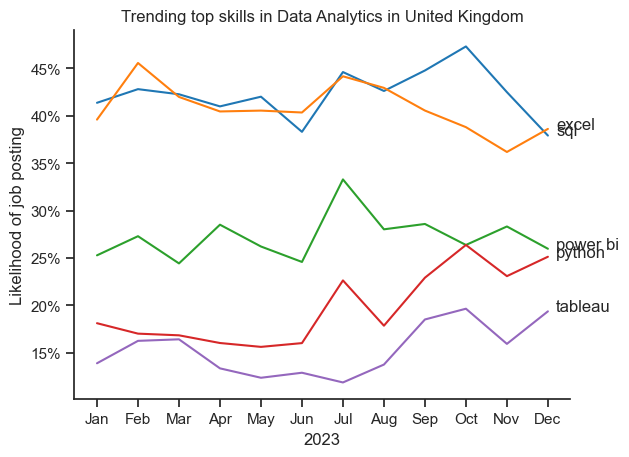

In [92]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()  #gca is get current axis
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.title(f'Trending top skills in Data Analytics in {country}')
plt.ylabel('Likelihood of job posting')
plt.xlabel('2023')
plt.legend().remove()

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i])

answered = answer(df_plot)
display(Markdown(answered))

    
    